# Hotel Booking Cancellation Analysis
## Project overview 
This project analyses hotel booking data to understand characteristics associated with booking cancellations. 

In [1]:
# Import libraries
import pandas as pd
import  seaborn as sns
import matplotlib.pyplot as plt
import numpy as py

In [2]:
#Loading data files
df =pd.read_csv("C:/Users/SEB/Downloads/PYTHON/PYTHON FOR DATA ANALYTICS & DATA APPS/Hotel Booking Analysis/hotel_bookings.csv")

In [3]:
#preview data
df.head

<bound method NDFrame.head of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   


In [4]:
# Shape of the data frame 
df.shape

(119390, 32)

In [5]:
# Dataset infromation
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
# Check for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# Data Cleaning

In [7]:
# Fill company and agent with 0 ( indicates customer booked directly for themselves)
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)


In [8]:
# Fill Children with 0
df['children'] = df['children'].fillna(0)

In [9]:
# Drop the rest of the missing values
df = df.dropna()

In [10]:
# Recheck for missing values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [11]:
# Fix data types
#convert float to integer
df['children'] = df['children'].astype(int)

In [12]:
# Remove dulpicates
df = df.drop_duplicates()

In [13]:
# Export the cleaned data
df.to_csv('Cleaned_Hotel_Booking.csv', index= False)

## Feature Engineering

In [14]:
# Calculate total_nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [15]:
# Calculate the total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [16]:
# Create Is_family(True if there are children or babies, False otherwise)
df['is_family'] = (df['children'] > 0) | (df['babies'] > 0)

In [17]:
# Create season based on arrival month
month_to_season ={
    'December':'Winter', 'January':'Winter', 'February':'Winter', 'March':'Spring',
    'April':'Spring', 'May':'Spring', 'June':'Summer', 'July':'Summer', 'August':'Summer',
    'September':'Fall', 'October':'Fall', 'November':'Fall'
    
    }
df['season'] = df['arrival_date_month'].map(month_to_season)

In [18]:
#Preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,False,Summer


# Exploratory Data Analysis (EDA)

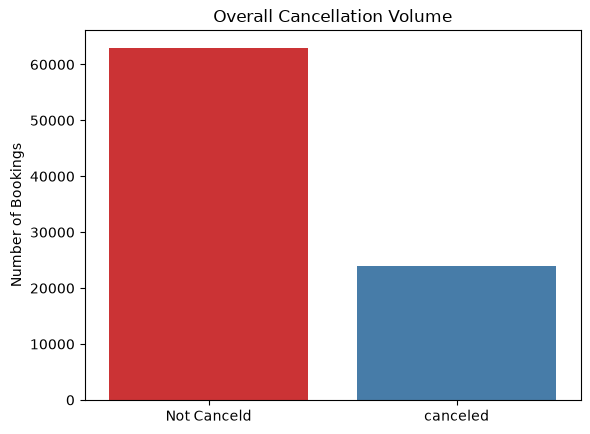

Overall Cancellation Rate: 27.6%


In [19]:
# What is the overall booking cancellation rate?
plt.Figure(figsize=(6,4))
# Mapping 0 and 1 to readable lables
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceld', 1: 'canceled'})

sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)

plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('cancellation.png')
plt.show()

#calculate the exact cancellation percentage
cancel_pct =df['is_canceled'].value_counts(normalize=True) * 100
print(f'Overall Cancellation Rate: {cancel_pct[1]:.1f}%')

The cancelation rate is 27.6% this means that 1 in 3 bookings is canceled, Thus the hotels cannot rely on the initial booking numbers for staffing or food ordering. Management must utulize an overbooking strategy to enxure the hotel is full on any given night.

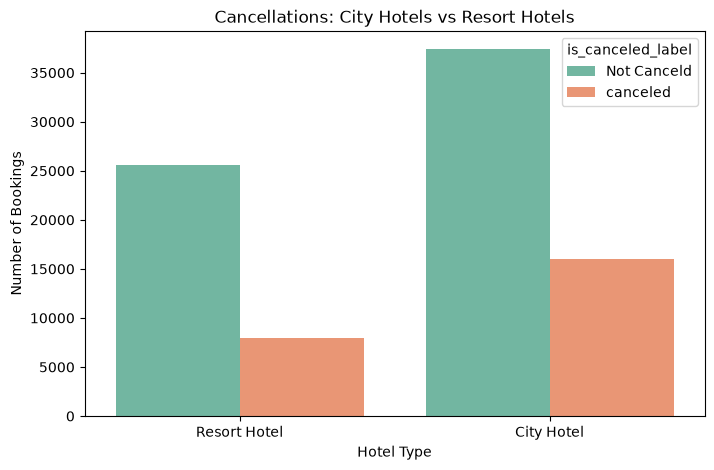

hotel         is_canceled
City Hotel    0              69.965557
              1              30.034443
Resort Hotel  0              76.296164
              1              23.703836
Name: proportion, dtype: float64

In [20]:
# Hotel type comparison
# does the hotel type affect the likelihood of cancellations? Wewill compare city hotels
# vs Resort hotels to see if their customers bases behave differently.
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellations: City Hotels vs Resort Hotels')
plt.ylabel('Number of Bookings')
plt.xlabel('Hotel Type')
plt.savefig('hoteltype.png')
plt.show()

# Calculate rates per hotel type
df.groupby('hotel')['is_canceled' ].value_counts(normalize=True) * 100

City hotels see significantly higher booking volumes and a much higher cancelation rate that resort Hotels. City trips are often short, implusive or tied to business meetings that get moved. Resort trips are usually planned so (often involve flights) making the guest less likely to cancel.

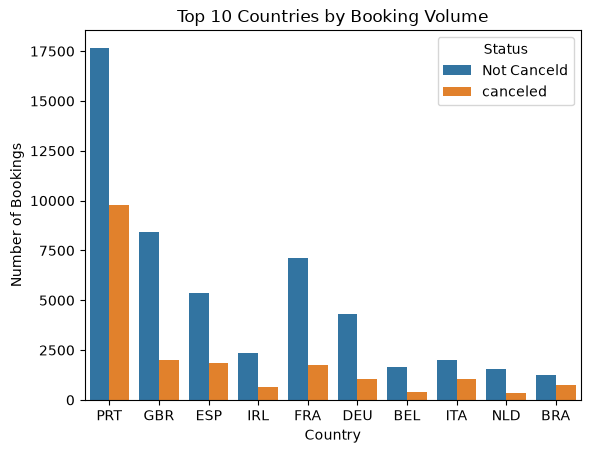

In [21]:
# Understanding the geographical origin of our customers how does it affect the cancelations
plt.Figure(figsize=(10,6))
# Top ten countries by volume
top_10_countries = df['country'].value_counts().head(10).index
sns.countplot(x='country', hue='is_canceled_label', data=df[df['country'].isin(top_10_countries)])
plt.title('Top 10 Countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('countries.png')
plt.show()


PRT(Portugal) generated the highest booking volume, but it also has a staggering cancellation rate. Because the
hotels in this dataset are from portugal, these are local residents. Locals often book multiple hotels as 'backups'
for weekend getaways because they don't have to commit to flights.

International guest rarely cancel because their bookings are locked in by airline tickets.

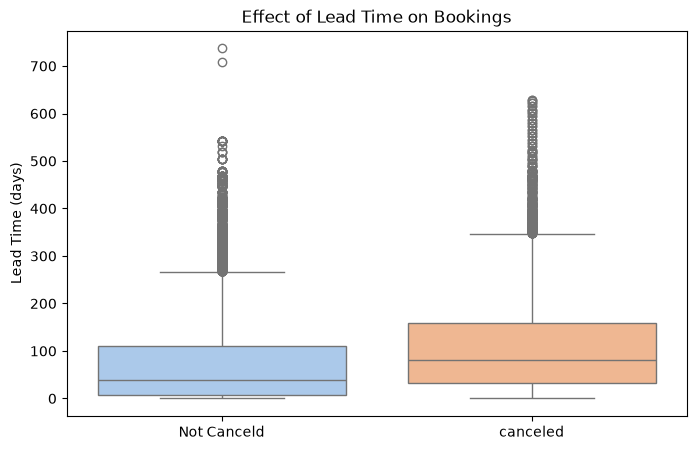

In [22]:
# Lead Time Analysis - Leadtime is the number of days between when the guest books and when they arrive
# Does booking in advance make the guest likely ot cancel?
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data = df, hue='is_canceled_label', palette='pastel', legend=False)
plt.title('Effect of Lead Time on Bookings')
plt.ylabel('Lead Time (days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The boxplot shows that the median leadtime for cancelled bookings is much higher. simply put: the earlier someone books the more time they have to change their mind.

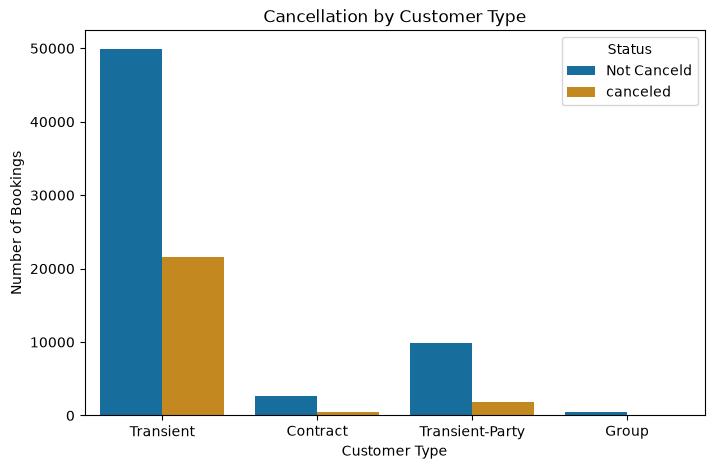

In [23]:
# Customer Type Analysis
# Are solo/transiet travellers more volatile than large groups or corprate contracts?
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data = df, palette='colorblind')

plt.title('Cancellation by Customer Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()

'Transient' travellers(Independent traveller not part of a group) account for the vast majority of both bookings and cancellations. Conversely, 'Groups' and 'Contract' bookings are much more stable.
Recommendation:
The sales team should prioritize securing more B2B contracts and groups events to build stable, guaranteed revenue base that protects against volatility of individual travellers 

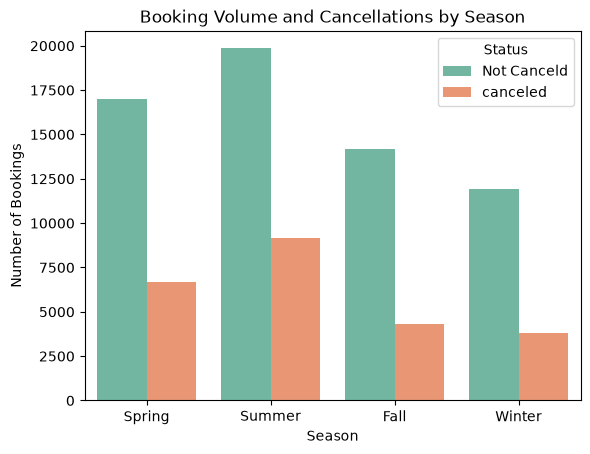

season  is_canceled
Fall    0              76.62
Winter  0              75.74
Spring  0              71.80
Summer  0              68.40
        1              31.60
Spring  1              28.20
Winter  1              24.26
Fall    1              23.38
Name: proportion, dtype: float64

In [24]:
#Seasonal Cancelation Analysis
plt.Figure(figsize=(8,5))

# Logical flow of seasons
Season_order= ['Spring','Summer','Fall','Winter']

sns. countplot(x='season', hue='is_canceled_label', data=df, order=Season_order, palette='Set2')

plt.title('Booking Volume and Cancellations by Season')
plt.ylabel('Number of Bookings')
plt.xlabel('Season')
plt.legend(title='Status')
plt.savefig('seasonal.png')
plt.show()

# Calculate the cancellation rate per season
season_cancel_rate = df.groupby('season') ['is_canceled'].value_counts(normalize=True) * 100
season_cancel_rate.round(2). sort_values (ascending=False)

Summer shows the highest total volume of bookings and the highest absolute number of cancellations.

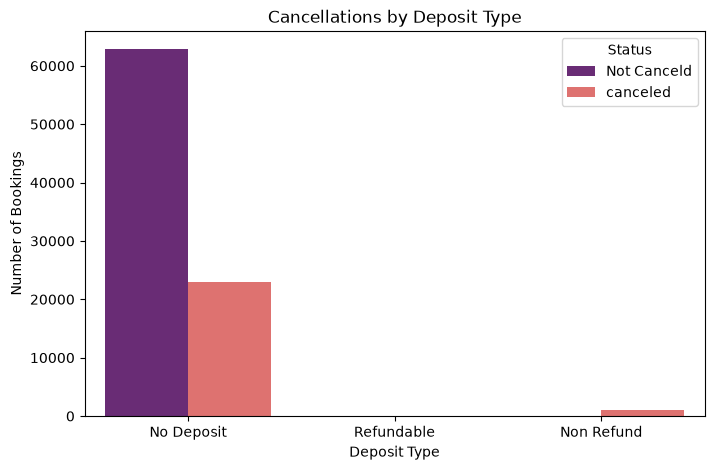

In [25]:
# Impact of Deposit type on cancellations
plt.figure(figsize=(8,5))
sns. countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='magma')
plt.title('Cancellations by Deposit Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Deposit Type')
plt. legend(title='Status')
plt.savefig('deposittype.png')
plt. show()

Majority of the bookings require no deposit. Our recommendation make the deposit compulsory and non refundable.